# Calculate `VPD` (2004-2025)

**notebook version**: `3` (29 Jul 2026)

## ℹ️ About this notebook

Computes vapour pressure deficit `VPD` from the two products that precede it, and stores it to the
external data folder. No download, no gap-filling: `02` and `04` must be run first.

- `TA_T1_47_1_gfXG` — gap-filled air temperature from notebook `02`, **complete**
- `RH_T1_47_1` — relative humidity from notebook `04`, **complete** (reconstructed where the tower
  did not measure)

`VPD` follows from `TA` and `RH` by formula. Both inputs are complete, so **VPD is computed for
every record** — there are no gaps to model, and the XGBoost step of earlier versions is gone.

`TA` and `RH` come from **one probe**, replaced together with its logger on 21 January 2016.
That change moved both inputs, so it moves `VPD`. Notebook `02` exports a homogenised `TA`
alongside the measured one; notebook `04` deliberately exports no homogenised `RH`, because the
`RH` step depends on the humidity itself and no constant removes it. `VPD` is therefore computed
on **two bases** and both are exported, on the same pattern as `08` and `09`.

`VPD` is computed from the **best available estimate of each input**: the homogenised `TA` from
notebook `02`, and the `RH` from notebook `04`. There is no homogenised `RH` — `04` measured a
level-dependent transfer and rejected it, because both eras of that probe drift by more than the
step between them.

**Output columns:**

- `VPD_T1_47_1` — the computed series (kPa, complete), from `TA_T1_47_1_HOMOGENIZED_gfXG` and
  `RH_T1_47_1`.
- `FLAG_VPD_T1_47_1_ISFILLED` — what each record was computed from; `0` = measured `TA` **and**
  measured `RH`, `>0` = one input was gap-filled or reconstructed (see `FLAG_LEGEND`).
- `FLAG_VPD_T1_47_1_SOURCE` — which probe generation stands behind the record.

There is deliberately **no `_HOMOGENIZED` column**. That name would assert that `VPD` is comparable
across 21 January 2016, and it is not: the temperature term is put on one consistent level, the
humidity term cannot be, and what remains is a step of roughly 17 % of the mean `VPD`. A second
column would invite exactly the conclusion the evidence refuses.

The section on the 2016 change measures that residual step, and measures it against the series
built on the *measured* `TA` as well. That comparison is the reason the product uses the
homogenised temperature: on the measured `TA` the step looks about three times smaller, not because
the record is better but because the pre-2016 `TA` error runs opposite to the `RH` error and masks
it. The masking is an accident of the two biases' signs and holds only at particular temperatures
and humidities, so it is not something a product should rest on.

Because `VPD` is **derived**, `0` still means "measured and nothing else": a record can be computed
by the formula yet rest on a gap-filled `TA` or a reconstructed `RH`, which the flag records.

***

## 📇 Data sources

Both inputs are parquet files in the external data folder, written by earlier notebooks in this
stage. Nothing is read from the database here.

| file | column used | from | completeness |
|---|---|---|---|
| `02_METEO_TA_GAPFILLED_2004-2025` | `TA_T1_47_1_gfXG` | notebook `02` | complete |
| `02_METEO_TA_GAPFILLED_2004-2025` | `FLAG_TA_T1_47_1_ISFILLED` | notebook `02` | complete |
| `04_METEO_RH_CORRECTED_2004-2025` | `RH_T1_47_1` | notebook `04` | complete |
| `04_METEO_RH_CORRECTED_2004-2025` | `FLAG_RH_T1_47_1_MISSING` | notebook `04` | complete |
| `02_METEO_TA_GAPFILLED_2004-2025` | `TA_T1_47_1_HOMOGENIZED_gfXG` | notebook `02` | complete |
| `02_METEO_TA_GAPFILLED_2004-2025` | `FLAG_TA_T1_47_1_SOURCE` | notebook `02` | complete |
| `04_METEO_RH_CORRECTED_2004-2025` | `FLAG_RH_T1_47_1_SOURCE` | notebook `04` | complete |
| `MeteoSwiss_LAE_30MIN_2004-2025` | `TA_LAE_MS`, `RH_LAE_MS` | `10_REFERENCE/` | reference only |

Both inputs are complete, so `VPD` is computed for every record. The two input flags are read as
well, not just the values: they are what makes the provenance of each computed `VPD` knowable —
without them every computed record would look equally measured.

## ⏱️ Timestamp convention

Every input file already carries a sanitised, continuous 30MIN `TIMESTAMP_MID` index in local time,
produced by the `TimestampSanitizer` call in the notebook that wrote it. This notebook does not
shift, resample or geolocate anything: it asserts that the two indices agree and computes `VPD` on
them as they are.

***

## ⚙️ Settings

### Data settings

In [1]:
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution of the input files; asserted below

TARGET = "VPD_T1_47_1"  # variable computed and exported here

# Inputs: products of the earlier notebooks of this stage, in the external data folder.
# There is no database download in this notebook.
TA_FILE = "02_METEO_TA_GAPFILLED_2004-2025"
TA_COL = "TA_T1_47_1_gfXG"
TA_FLAGCOL = "FLAG_TA_T1_47_1_ISFILLED"

RH_FILE = "04_METEO_RH_CORRECTED_2004-2025"
RH_COL = "RH_T1_47_1"
RH_FLAGCOL = "FLAG_RH_T1_47_1_MISSING"
RH_FLAG_RECONSTRUCTED = 3      # notebook 04: reconstructed from NABEL at 49 m
RH_FLAG_RECONSTRUCTED_LAE = 4  # notebook 04: reconstructed from MeteoSwiss Laegern at 2.5 km

# --- The second basis ---------------------------------------------------------------------------
# TA and RH arrive from ONE probe in one sensor call (Rotronic MP101A read as an analog voltage,
# then a Campbell CS215 on SDI-12), replaced together with the logger on 2016-01-21. Notebook 02
# exports a homogenised TA beside the measured one; notebook 04 exports no homogenised RH, because
# that step is level-dependent and no constant reaches both ends of the range. So the homogenised
# VPD below corrects the temperature term only, and the 2016 section measures what that is worth.
TA_HOM_COL = "TA_T1_47_1_HOMOGENIZED_gfXG"
TA_SOURCECOL = "FLAG_TA_T1_47_1_SOURCE"
RH_SOURCECOL = "FLAG_RH_T1_47_1_SOURCE"

# Reference: MeteoSwiss Laegern, 2.5 km from the tower, stored on TIMESTAMP_END. It carries both
# TA and RH, so a reference VPD follows from the same formula. Neither of 02's correction terms was
# fitted against this station -- 02 fits against NABEL on the same tower -- so scoring against it
# is a test rather than a restatement of a fit. Addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL_TA = "TA_LAE_MS"
REFCOL_RH = "RH_LAE_MS"

# The acquisition change, from notebooks 02 and 04: the last record of the analog era and the
# first of the SDI-12 era are 20 days apart, and 2016 belongs to neither era.
ACQUISITION_CHANGE = '2016-01-21 14:15:00'
BREAK_YEAR = 2016


# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "07_METEO_VPD_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Plausible VPD at this site, in kPa. VPD is zero at saturation and cannot be negative; the upper
# bound is generous (the record maximum is around 4 kPa) and only has to catch a unit or formula
# error, which would be off by a factor of 10 (hPa) or more.
VPD_PLAUSIBLE_KPA = (0.0, 10.0)

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-29 20:52:04
diive version: v0.91.0


In [3]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 03.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


In [4]:
# Result flags. VPD is DERIVED and, since notebooks 02 and 04 now export complete TA and RH, it is
# COMPUTED for every record -- no VPD model runs here, so there are no modelled flags (1/2/4).
#
# A computed record still need not rest on two measurements: notebook 02 may have gap-filled the TA,
# or notebook 04 may have reconstructed the RH (from NABEL, or from MeteoSwiss Laegern). Those are
# not measurements, so they must not read 0.
#
# The 01-03 convention holds: 0 means measured and nothing else, so a downstream `flag == 0` filter
# stays conservative.
FLAG_LEGEND = {
    0: '0 = computed from measured TA and measured RH',
    5: '5 = computed from measured RH and gap-filled TA',
    6: '6 = computed from RH reconstructed from NABEL at 49 m (TA measured or gap-filled)',
    7: '7 = computed from RH reconstructed from MeteoSwiss Laegern at 2.5 km (TA measured or gap-filled)',
}
# Every VPD record follows from the formula -- all flags are "computed" flags.
COMPUTED_FLAGS = (0, 5, 6, 7)

# Probe generation behind each record, carried over from notebooks 02 and 04 unchanged. TA and RH
# come from one probe, so their SOURCE flags are the same flag; that is asserted below rather than
# taken on trust, and this legend is theirs.
SOURCE_LEGEND = {
    0: '0 = Campbell CS215 on SDI-12 (from 2016-01-21)',
    1: '1 = Rotronic MP101A, single-ended analog (to 2015-12-31)',
    2: '2 = acquisition changeover, probe generation undetermined',
    3: '3 = before the tower record begins',
}


### Helper functions

Three helpers, each with the job of failing loudly rather than quietly doing nothing:

- `load_product()` reads one of the input files and **refuses** anything whose index is not a
  continuous, duplicate-free 30MIN series or that is missing the columns asked for. Every later
  step aligns three files on a shared index, and a silently mis-shaped input would produce a
  `VPD` full of `NaN` that still had the right length.
- `short_gap_mask()` selects whole gap runs no longer than a limit. Same helper as notebook `02`.
- `check_vpd_range()` is the physical guard on the result, used twice: on the computed `VPD` and
  again on the exported series.

In [5]:
def load_product(filename: str, columns: list[str]) -> pd.DataFrame:
    """Load one stage-10 product and verify it is usable as an input here.

    Raises rather than returning a frame that would quietly poison the merge: missing columns, a
    non-30MIN index, duplicate timestamps or an index with holes all stop the notebook.
    """
    filepath = Path(OUTPATH) / f"{filename}.parquet"
    if not filepath.is_file():
        raise FileNotFoundError(
            f"{filepath} does not exist. Run the notebook that produces it before this one.")

    df = dv.load_parquet(filepath=str(filepath))

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"{filename}: expected column(s) {missing}, found {list(df.columns)}.")
    if df.index.duplicated().any():
        raise ValueError(f"{filename}: {int(df.index.duplicated().sum())} duplicate timestamps.")

    steps = df.index.to_series().diff().dropna().unique()
    expected = pd.Timedelta(REQUIRED_TIME_RESOLUTION)
    if len(steps) != 1 or steps[0] != expected:
        raise ValueError(
            f"{filename}: index is not a continuous {REQUIRED_TIME_RESOLUTION} series "
            f"(found step(s) {list(steps)}).")

    out = df[columns].copy()
    print(f"  {filename:<38} {out.index[0]} -> {out.index[-1]}  ({len(out):,} records)")
    return out


def short_gap_mask(series: pd.Series, limit: int) -> pd.Series:
    """True where `series` is missing AND its whole gap is at most `limit` records long.

    Whole runs are selected explicitly. Using pandas' `interpolate(limit=)` instead would fill
    the first `limit` records of a long gap as well, which is not wanted: those values would sit
    on a straight line spanning the entire gap.
    """
    missing = series.isna()
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def check_vpd_range(series: pd.Series, label: str) -> None:
    """Assert that every value present is plausible VPD in kPa.

    A formula slip or a unit mix-up (hPa instead of kPa) shows up here as a factor of 10, and a
    negative value means either an RH above 100% survived upstream or a model prediction was not
    clipped.
    """
    lo, hi = VPD_PLAUSIBLE_KPA
    values = series.dropna()
    if values.empty:
        raise ValueError(f"{label}: no values at all.")
    if values.min() < lo or values.max() > hi:
        raise ValueError(
            f"{label}: range {values.min():.3f}..{values.max():.3f} kPa is outside the plausible "
            f"{lo}..{hi} kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.")
    print(f"  {label:<34} n={len(values):>7,}  "
          f"median {float(values.median()):.3f}  range {values.min():.3f}..{values.max():.3f} kPa")

#### The guards actually guard

Both `load_product()` and `check_vpd_range()` can only earn their place if their failure path
works, so it is exercised here. Each of these must raise. If this cell prints anything other than
caught exceptions, do not trust the rest of the notebook.

In [6]:
# 1. A column that does not exist must be refused, not silently dropped.
try:
    load_product(TA_FILE, [TA_COL, 'NO_SUCH_COLUMN'])
    raise AssertionError("load_product accepted a missing column - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}\n")

# 2. VPD in hPa (i.e. 10x too large) must be refused.
try:
    check_vpd_range(pd.Series([5.0, 12.0, 30.0]), 'VPD in hPa by mistake')
    raise AssertionError("check_vpd_range accepted hPa-magnitude values - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}\n")

# 3. A negative VPD must be refused.
try:
    check_vpd_range(pd.Series([0.4, -0.01, 1.2]), 'VPD with a negative value')
    raise AssertionError("check_vpd_range accepted a negative VPD - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.037 seconds).

OK, raised as intended:
  02_METEO_TA_GAPFILLED_2004-2025: expected column(s) ['NO_SUCH_COLUMN'], found ['TA_T1_47_1_gfXG', 'FLAG_TA_T1_47_1_ISFILLED', 'TA_T1_47_1_HOMOGENIZED_gfXG', 'FLAG_TA_T1_47_1_SOURCE'].

OK, raised as intended:
  VPD in hPa by mistake: range 5.000..30.000 kPa is outside the plausible 0.0..10.0 kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.

OK, raised as intended:
  VPD with a negative value: range -0.010..1.200 kPa is outside the plausible 0.0..10.0 kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.


***

## ⬇️ Load inputs

No database connection is needed. The three files below are read from the external data folder,
each of them the output of an earlier notebook in this stage.

In [7]:
print("Loading stage-10 products:")
ta_in = load_product(TA_FILE, [TA_COL, TA_HOM_COL, TA_FLAGCOL, TA_SOURCECOL])
rh_in = load_product(RH_FILE, [RH_COL, RH_FLAGCOL, RH_SOURCECOL])

Loading stage-10 products:


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.010 seconds).

  02_METEO_TA_GAPFILLED_2004-2025        2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\04_METEO_RH_CORRECTED_2004-2025.parquet (0.007 seconds).

  04_METEO_RH_CORRECTED_2004-2025        2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)

### Align on one index

The three files are expected to cover the same period, but that is asserted rather than assumed.
The working index is their **intersection**, so a future input with a shorter record shortens the
product instead of filling the difference with `NaN` that would later be modelled as if it were a
genuine gap.

In [8]:
common_index = ta_in.index.intersection(rh_in.index)
common_index.name = ta_in.index.name

for _label, _df in [('TA', ta_in), ('RH', rh_in)]:
    _dropped = len(_df) - len(common_index)
    print(f"{_label:<6} {len(_df):>7,} records, {_dropped:>5,} outside the common index")
assert len(common_index) > 0, "the two inputs do not overlap at all"

df = pd.DataFrame(index=common_index)
df[TA_COL] = ta_in[TA_COL]
df[TA_HOM_COL] = ta_in[TA_HOM_COL]
df[TA_FLAGCOL] = ta_in[TA_FLAGCOL]
df[TA_SOURCECOL] = ta_in[TA_SOURCECOL]
df[RH_COL] = rh_in[RH_COL]
df[RH_FLAGCOL] = rh_in[RH_FLAGCOL]
df[RH_SOURCECOL] = rh_in[RH_SOURCECOL]

print(f"\nWorking index: {df.index[0]} -> {df.index[-1]}  ({len(df):,} records)")

# Both inputs arrive complete, so VPD can be computed for every record.
assert df[TA_COL].notna().all(), f"{TA_COL} has gaps but notebook 02 exports a complete series"
assert df[RH_COL].notna().all(), f"{RH_COL} has gaps but notebook 04 now exports a complete series"
assert df[TA_FLAGCOL].notna().all(), f"{TA_FLAGCOL} has missing flags"
assert df[RH_FLAGCOL].notna().all(), f"{RH_FLAGCOL} has missing flags"
assert df[TA_HOM_COL].notna().all(), f"{TA_HOM_COL} has gaps but notebook 02 exports it complete"
print(f"{RH_COL}: complete, so VPD is computed for every record")

# TA and RH arrive from one probe in one sensor call, so notebooks 02 and 04 must describe the
# same generations at the same timestamps. If they ever disagree, one of the two products has
# the sensor history wrong and the SOURCE flag exported below would inherit it.
assert df[TA_SOURCECOL].equals(df[RH_SOURCECOL]), (
    "the TA and RH SOURCE flags disagree, though both describe the same probe")
print(f"{TA_SOURCECOL} and {RH_SOURCECOL} are identical, as one probe requires")
df

TA     385,728 records,     0 outside the common index
RH     385,728 records,     0 outside the common index

Working index: 2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
RH_T1_47_1: complete, so VPD is computed for every record
FLAG_TA_T1_47_1_SOURCE and FLAG_RH_T1_47_1_SOURCE are identical, as one probe requires


,TA_T1_47_1_gfXG,TA_T1_47_1_HOMOGENIZED_gfXG,FLAG_TA_T1_47_1_ISFILLED,FLAG_TA_T1_47_1_SOURCE,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING,FLAG_RH_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,,,,,,
2004-01-01 00:15:00,-3.771351,-2.451677,5,3,97.718962,3,3
2004-01-01 00:45:00,-3.670024,-2.350349,5,3,96.918962,3,3
2004-01-01 01:15:00,-3.636248,-2.316573,5,3,93.552296,3,3
2004-01-01 01:45:00,-3.737576,-2.417901,5,3,92.652296,3,3
2004-01-01 02:15:00,-3.906455,-2.586781,5,3,93.985629,3,3
...,...,...,...,...,...,...,...
2025-12-31 21:45:00,-3.081644,-3.081644,0,0,42.332976,0,0
2025-12-31 22:15:00,-3.084372,-3.084372,0,0,39.230344,0,0
2025-12-31 22:45:00,-3.423939,-3.423939,0,0,55.771803,0,0


### Provenance carried by the inputs

Where the non-`0` codes sit decides which `VPD` records can be labelled `0` further down. Notebook
`02`'s flag names the model that produced a `TA`; notebook `04`'s flag says whether an `RH` was
measured at 47 m, reconstructed from NABEL, or is simply absent.

In [9]:
_ta_counts = df[TA_FLAGCOL].value_counts().sort_index()
_rh_counts = df[RH_FLAGCOL].value_counts().sort_index()

print(f"{TA_FLAGCOL} (0 = measured, > 0 = gap-filled by notebook 02):")
tabcap("how notebook 02 produced each TA record. Codes above 0 are gap-filled, so a VPD computed from them is not a VPD from two measurements")
display(pd.DataFrame({'count': _ta_counts, '%': (100 * _ta_counts / len(df)).round(2)}))

print(f"{RH_FLAGCOL} (0 = measured, 3 = reconstructed from NABEL, 4 = reconstructed from Laegern):")
tabcap("how notebook 04 produced each RH record. RH enters the formula linearly, so a reconstructed RH carries further into VPD than a gap-filled TA does")
display(pd.DataFrame({'count': _rh_counts, '%': (100 * _rh_counts / len(df)).round(2)}))

FLAG_TA_T1_47_1_ISFILLED (0 = measured, > 0 = gap-filled by notebook 02):
Table - how notebook 02 produced each TA record. Codes above 0 are gap-filled, so a VPD computed
from them is not a VPD from two measurements



,count,%
FLAG_TA_T1_47_1_ISFILLED,,
0,369065,95.68
1,14912,3.87
2,43,0.01
4,178,0.05
5,1530,0.40


FLAG_RH_T1_47_1_MISSING (0 = measured, 3 = reconstructed from NABEL, 4 = reconstructed from Laegern):
Table - how notebook 04 produced each RH record. RH enters the formula linearly, so a reconstructed
RH carries further into VPD than a gap-filled TA does



,count,%
FLAG_RH_T1_47_1_MISSING,,
0,369079,95.68
3,15729,4.08
4,920,0.24


***

## 🧮 Calculate `VPD`

`VPD` is the difference between the saturation vapour pressure at the given air temperature and the
actual vapour pressure, so it follows from `TA` and `RH` alone:

$$
\mathrm{VPD} = e_{sat}(T_a)\left(1 - \frac{\mathrm{RH}}{100}\right)
$$

`diive`'s `calc_vpd_from_ta_rh()` implements this with the Magnus coefficients used by **ReddyProc**
(Kolle Logger Tools Software 2012, valid for water between 0 and 100 °C) and returns **kPa**:

```
VPD [hPa] = 6.1078 * (1 - RH/100) * exp(17.08085 * TA / (234.175 + TA))
```

Two consequences of the formula are worth stating before the numbers appear:

- **`VPD` is zero at saturation and never negative.** `RH` arrives from notebook `04` already
  capped at 100%, so the computed series cannot be negative. The model predictions later on can be,
  and are clipped where they are.
- **`VPD` is missing exactly where `RH` is missing**, because `TA` is complete. So the gap pattern
  of the computed series is `RH`'s gap pattern, and that is checked rather than assumed.

In [10]:
# The PRODUCT uses the homogenised TA: it is the best available temperature, and the whole
# record is then on one consistent temperature level. The series built on the measured TA is
# computed too, but only as a DIAGNOSTIC - the comparison between the two is what shows where
# the residual 2016 step in VPD comes from. It is not exported.
DIAG_MEASURED_TA = "_VPD_FROM_MEASURED_TA"

df[TARGET] = dv.variables.calc_vpd_from_ta_rh(df=df, rh_col=RH_COL, ta_col=TA_HOM_COL)
df[DIAG_MEASURED_TA] = dv.variables.calc_vpd_from_ta_rh(df=df, rh_col=RH_COL, ta_col=TA_COL)

print("Computed VPD:")
check_vpd_range(df[TARGET], TARGET)
check_vpd_range(df[DIAG_MEASURED_TA], DIAG_MEASURED_TA + ' (diagnostic)')

# 02 homogenises TA with TWO terms, and both of them reach VPD:
#   - a constant +1.3197 degC that raises the earlier era onto the later era's level, and
#   - a radiation-shield term applied to the LATER era, never positive and exactly zero in the
#     dark, which removes the difference between the two shields' responses to sunlight.
# So the later era is NOT left untouched, and an assertion saying it is would repeat a mistake
# 02 made and fixed. What holds is the SIGN of each term; VPD rises monotonically with TA, so
# both signs carry through the formula unchanged.
_later = df.index >= pd.Timestamp(ACQUISITION_CHANGE)
_earlier = ~_later
_d_hom = df[TARGET] - df[DIAG_MEASURED_TA]

# At saturation VPD is 0 on both bases whatever the temperature, so the earlier era is raised
# everywhere EXCEPT where RH is exactly 100%. Stating it that way makes the exception physical
# rather than a tolerance.
assert (_d_hom[_earlier] >= 0).all(), "the earlier era is lowered somewhere on the homogenised basis"
assert (_d_hom[_earlier][df.loc[_earlier, RH_COL] < 100] > 0).all(), \
    "the earlier era is not raised at every unsaturated record"

assert (_d_hom[_later] <= 1e-9).all(), "the later era's shield term must never raise VPD"
assert (_d_hom[_later] < -1e-9).any(), "the later era carries no shield term at all - has 02 changed?"
# The shield term follows the radiation, so it must take many values rather than behaving like a
# second constant, and it must be exactly zero wherever there was nothing to correct.
assert _d_hom[_later].nunique() > 1000, "the later-era correction looks like a second constant"
assert (_d_hom[_later] == 0).sum() > 10_000, "the later-era correction is never exactly zero"

print(f"\nProduct vs the measured-TA diagnostic: earlier era raised at every unsaturated "
      f"record; later era\n  never raised, {int((_d_hom[_later] == 0).sum()):,} of "
      f"{int(_later.sum()):,} later records identical (no radiation, or saturated).")

# The gap pattern must be RH's gap pattern and nothing else. If these ever disagree, either TA
# arrived incomplete or the formula produced NaN from valid inputs; both are bugs, not data.
_vpd_missing = df[TARGET].isna()
_rh_missing = df[RH_COL].isna()
print(f"\nVPD missing: {int(_vpd_missing.sum()):,}   RH missing: {int(_rh_missing.sum()):,}")
assert _vpd_missing.equals(_rh_missing), \
    "VPD is missing where RH is not (or vice versa) - TA incomplete, or a formula problem"
print("VPD gaps are exactly RH's gaps, as expected.")

Computed VPD:
  VPD_T1_47_1                        n=385,728  median 0.179  range 0.000..4.345 kPa
  _VPD_FROM_MEASURED_TA (diagnostic) n=385,728  median 0.170  range 0.000..4.036 kPa

Product vs the measured-TA diagnostic: earlier era raised at every unsaturated record; later era
  never raised, 83,986 of 174,356 later records identical (no radiation, or saturated).

VPD missing: 0   RH missing: 0
VPD gaps are exactly RH's gaps, as expected.


### Provenance of the computed `VPD`

Every record that has a value at this point was computed by the formula, so **none of it is
modelled**. That is not the same as measured, and this is where the distinction is written down
rather than left to be inferred later.

A computed record gets:

- `0` if both inputs were measurements (`TA` flag `0` **and** `RH` flag `0`)
- `5` if `RH` was measured but `TA` came from notebook `02`'s gap-filling
- `6` if `RH` was reconstructed from the NABEL sensor at 49 m, whatever `TA` was

`6` outranks `5` because it is the larger error: notebook `04` puts about **3 % RH** of uncertainty
on a reconstructed value, and `RH` enters the formula linearly, so at typical summer conditions
that is a few tenths of a kPa — considerably more than a gap-filled `TA` contributes.

The mask is built **now**, before any gap-filling writes values into the missing records. Doing it
afterwards is precisely the mistake notebook `03` records: a later step that puts a value into an
empty record makes a modelled value indistinguishable from a measured one.

In [11]:
# TA and RH are complete, so VPD is computed for every record. The flag records what each VPD
# rests on; there is no gap-filling to merge in.
computed = df[TARGET].notna()
assert computed.all(), "VPD is not complete though TA and RH are - a formula problem"

flag = pd.Series(pd.NA, index=df.index, dtype='Int64', name=f"FLAG_{TARGET}_ISFILLED")
flag[(df[TA_FLAGCOL] == 0) & (df[RH_FLAGCOL] == 0)] = 0                 # both measured
flag[(df[TA_FLAGCOL] > 0) & (df[RH_FLAGCOL] == 0)] = 5                  # RH measured, TA gap-filled
flag[df[RH_FLAGCOL] == RH_FLAG_RECONSTRUCTED] = 6                       # RH from NABEL (any TA)
flag[df[RH_FLAGCOL] == RH_FLAG_RECONSTRUCTED_LAE] = 7                   # RH from Laegern (any TA)

# The RH flag partitions the record into {0, 3, 4}, so every record is classified exactly once.
assert flag.notna().all(), "a record was left unclassified"
assert set(int(x) for x in flag.unique()).issubset(set(FLAG_LEGEND)), "unknown flag code"

_counts = flag.value_counts().sort_index()
tabcap("what each computed VPD record rests on. Every record is computed by the formula; the code says whether both inputs were measurements, and which one was not")
display(pd.DataFrame({'count': _counts.astype(int),
                      '% of record': (100 * _counts / len(df)).round(2)}).rename(index=FLAG_LEGEND))
print(f"All {len(df):,} records computed  |  purely measured (flag 0): {100 * (flag == 0).mean():.2f}%")

Table - what each computed VPD record rests on. Every record is computed by the formula; the code
says whether both inputs were measurements, and which one was not



,count,% of record
FLAG_VPD_T1_47_1_ISFILLED,,
0 = computed from measured TA and measured RH,369056,95.68
5 = computed from measured RH and gap-filled TA,23,0.01
6 = computed from RH reconstructed from NABEL at 49 m (TA measured or gap-filled),15729,4.08
7 = computed from RH reconstructed from MeteoSwiss Laegern at 2.5 km (TA measured or gap-filled),920,0.24


All 385,728 records computed  |  purely measured (flag 0): 95.68%


### Plots: the computed series and its inputs

The two heatmaps of the inputs and the one of `VPD` should share the same white areas, since `TA`
is complete and `RH` is not. `VPD` has a strong diurnal and seasonal structure — high on summer
afternoons, near zero at night and in winter — and a heatmap that does not show it would mean the
timestamps or the formula are wrong.

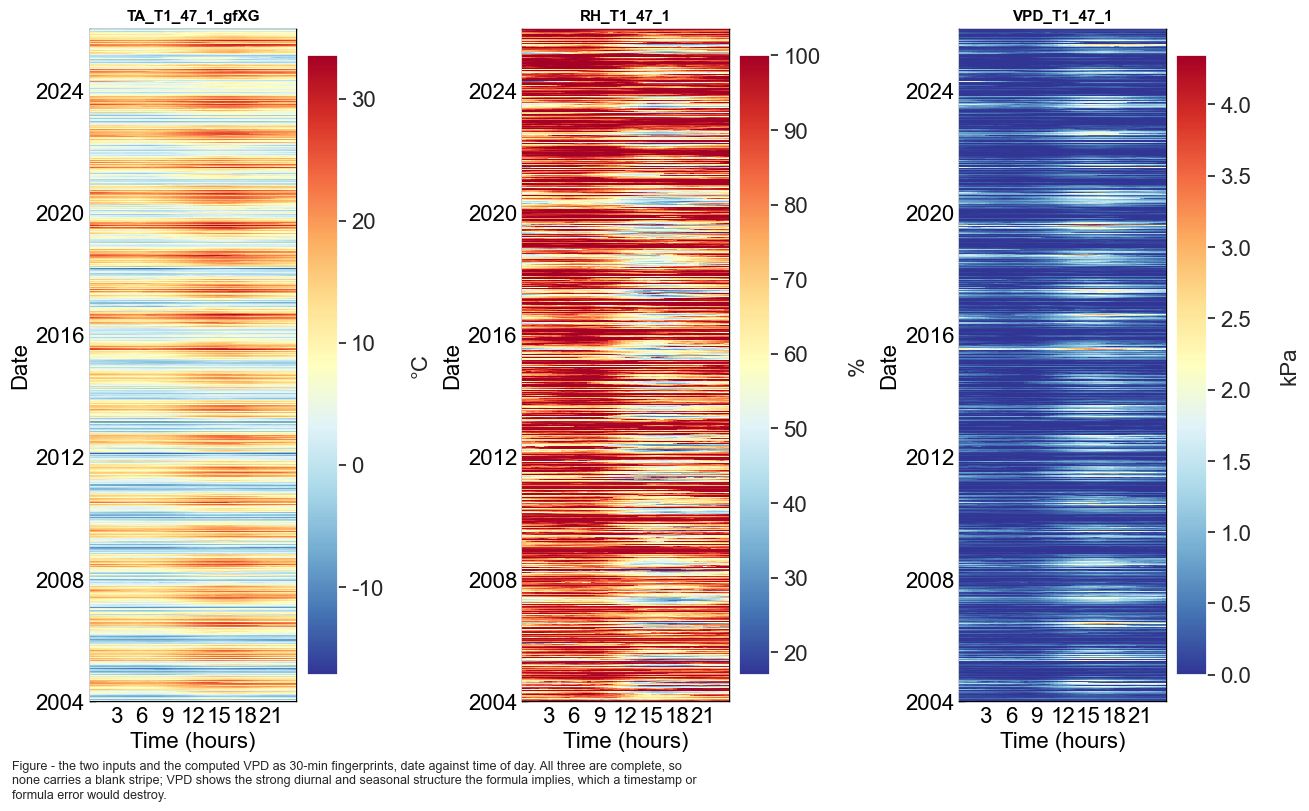

In [12]:
fig, axs = plt.subplots(ncols=3, figsize=(13, 8), dpi=100, layout='constrained')
for _ax, _col, _z, _dig in [(axs[0], TA_COL, '°C', 0),
                            (axs[1], RH_COL, '%', 0),
                            (axs[2], TARGET, 'kPa', 1)]:
    dv.plotting.HeatmapDateTime(series=df[_col]).plot(
        ax=_ax, cb_digits_after_comma=_dig, zlabel=_z,
        format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))
figcap(fig, "the two inputs and the computed VPD as 30-min fingerprints, date against time of "
            "day. All three are complete, so none carries a blank stripe; VPD shows the strong "
            "diurnal and seasonal structure the formula implies, which a timestamp or formula "
            "error would destroy.")

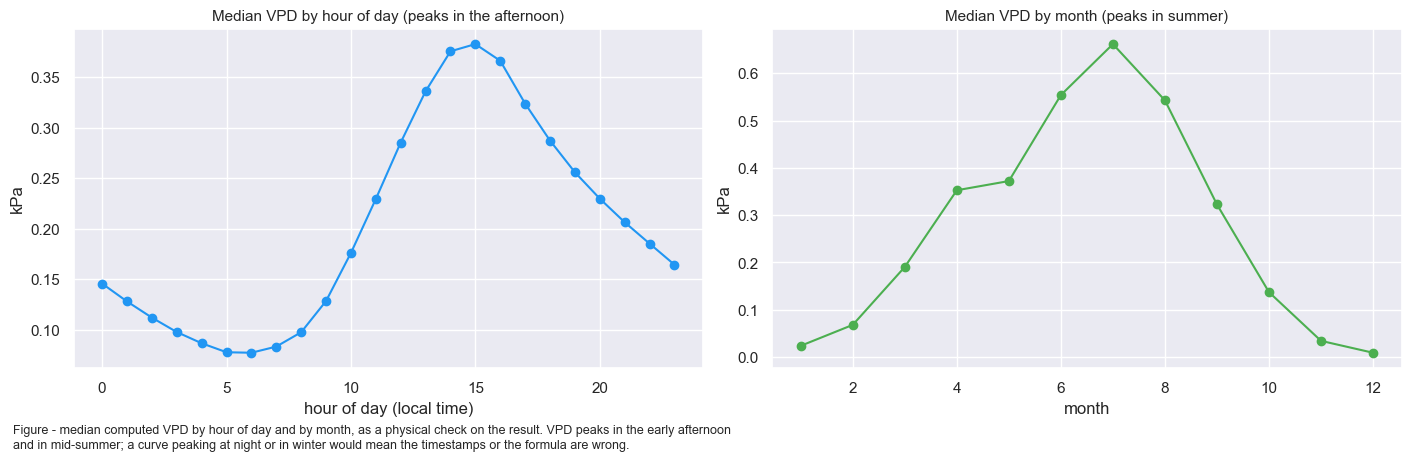

In [13]:
# Diurnal and seasonal behaviour of the computed VPD, as a second check that it is physical.
fig, axs = plt.subplots(ncols=2, figsize=(14, 4.5), dpi=100, layout='constrained')

_by_hour = df[TARGET].groupby(df.index.hour).median()
_by_hour.plot(ax=axs[0], marker='o', color='#2196F3')
axs[0].set_xlabel('hour of day (local time)')
axs[0].set_ylabel('kPa')
axs[0].set_title('Median VPD by hour of day (peaks in the afternoon)', fontsize=11)

_by_month = df[TARGET].groupby(df.index.month).median()
_by_month.plot(ax=axs[1], marker='o', color='#4CAF50')
axs[1].set_xlabel('month')
axs[1].set_ylabel('kPa')
axs[1].set_title('Median VPD by month (peaks in summer)', fontsize=11)
figcap(fig, "median computed VPD by hour of day and by month, as a physical check on the result. "
            "VPD peaks in the early afternoon and in mid-summer; a curve peaking at night or in "
            "winter would mean the timestamps or the formula are wrong.")

***

## 🔎 What the 2016 acquisition change does to `VPD`

`TA` and `RH` arrive from **one probe**, replaced together with its logger on 21 January 2016. Both
inputs step at that date, and they step in directions that act on `VPD` in **opposition**: the
earlier `TA` reads about 1.3 °C too cold, which lowers saturation vapour pressure and pulls `VPD`
down, while the earlier `RH` reads a few percentage points too dry, which pushes `VPD` up.

The question here is therefore not whether the homogenised `TA` is the more accurate temperature —
notebook `02` settles that against NABEL. It is whether a `VPD` built on it is **closer to
homogeneous across 2016** than one built on the measured `TA`. Correcting one of two opposing terms
can leave a larger step than correcting neither, so the answer is measured rather than assumed.

The test is against **MeteoSwiss Lägern**, 2.5 km away, whose own `TA` and `RH` give a reference
`VPD` by the same formula. Notebook `02` fitted its correction terms against NABEL on this tower and
never against MeteoSwiss, so this reference has seen neither correction: the comparison is a test,
not a restatement of a fit. Only records computed from two measurements (flag `0`) enter it, so a
reconstructed `RH` or a gap-filled `TA` cannot carry the result.

The station sits about 400 m lower than the tower, so a constant offset between the two `VPD`
series is expected and means nothing. Only the **change** in that offset across 2016 is evidence.


In [14]:
# Reference VPD from MeteoSwiss Laegern, by the same formula from that station's own TA and RH.
_ref = pd.read_parquet(REFPATH)[[REFCOL_TA, REFCOL_RH]].copy()
_ref.index = _ref.index - pd.Timedelta(minutes=15)   # TIMESTAMP_END -> TIMESTAMP_MID
_ref.index.name = df.index.name
_ref = _ref.dropna()
_ref['VPD_REF'] = dv.variables.calc_vpd_from_ta_rh(df=_ref, rh_col=REFCOL_RH, ta_col=REFCOL_TA)
check_vpd_range(_ref['VPD_REF'], 'VPD_REF (MeteoSwiss Laegern)')

# Purely measured records only.
_measured = flag == 0
_cmp = pd.concat([df.loc[_measured, [TARGET, DIAG_MEASURED_TA]], _ref['VPD_REF']],
                 axis=1, sort=False).dropna()
_cmp = _cmp[_cmp.index.year >= 2005]
print(f"\nComparison records: {len(_cmp):,}   {_cmp.index[0]} -> {_cmp.index[-1]}")
assert len(_cmp) > 100_000, "too few overlapping measured records to judge the step"


  VPD_REF (MeteoSwiss Laegern)       n=383,934  median 0.165  range 0.000..3.710 kPa

Comparison records: 363,868   2005-01-01 00:15:00 -> 2025-12-31 23:45:00


In [15]:
def _residual(col):
    """Tower minus MeteoSwiss VPD, on the measured records only."""
    return _cmp[col] - _cmp['VPD_REF']


def _step(col):
    """Mean residual before and after the break, and the change between them.

    2016 itself belongs to neither era - the changeover happened inside it - so it is excluded
    from both, exactly as notebook 02 does for TA.
    """
    _res = _residual(col)
    _pre = _res[(_res.index.year >= 2005) & (_res.index.year <= BREAK_YEAR - 1)].mean()
    _post = _res[_res.index.year >= BREAK_YEAR + 1].mean()
    return _pre, _post, _post - _pre


def _ordinary(col):
    """Median absolute change in the residual between ordinary consecutive years.

    The scale a step must be judged against is not zero: two stations 2.5 km apart drift against
    each other from year to year anyway. The three years around the break are dropped so the event
    cannot set its own threshold.
    """
    _res = _residual(col)
    _yr = _res.groupby(_res.index.year).mean()
    _d = _yr.diff().abs()
    # Drop the differences that SPAN the changeover rather than dropping the years first: removing
    # 2015-2017 from the series before differencing would leave a 2014->2018 gap masquerading as
    # one ordinary year-to-year change and inflate the threshold the step is judged against.
    _d = _d.drop(index=[y for y in (BREAK_YEAR, BREAK_YEAR + 1) if y in _d.index])
    return float(_d.median())


_mean_ref = float(_cmp['VPD_REF'].mean())
_rows = []
for _label, _col in [('homogenised TA (the product)', TARGET),
                     ('measured TA (diagnostic only)', DIAG_MEASURED_TA)]:
    _pre, _post, _stp = _step(_col)
    _rows.append({'basis': _label,
                  'pre-2016 (kPa)': round(_pre, 4),
                  'post-2016 (kPa)': round(_post, 4),
                  'step (kPa)': round(_stp, 4),
                  'step / mean VPD (%)': round(100 * _stp / _mean_ref, 2),
                  'ordinary-year change (kPa)': round(_ordinary(_col), 4)})

tabcap("the step in the tower-minus-MeteoSwiss VPD residual across the January 2016 acquisition "
       "change, for each of the two bases, against what the same residual does between ordinary "
       "consecutive years. A basis is the more homogeneous one where the step is smaller relative "
       "to that ordinary-year scale. Measured records only (flag 0); 2016 excluded from both eras")
display(pd.DataFrame(_rows).set_index('basis'))

_s_prod = abs(_step(TARGET)[2])
_s_diag = abs(_step(DIAG_MEASURED_TA)[2])
print(f"|step|, the product (homogenised TA): {_s_prod:.4f} kPa")
print(f"|step|, diagnostic (measured TA):     {_s_diag:.4f} kPa")

# The product's step is the LARGER of the two, and that is the expected result rather than a
# problem with it: the pre-2016 TA error lowers VPD while the pre-2016 RH error raises it, so
# a VPD carrying both errors reports a smaller step than the humidity record actually has.
# Correcting the temperature removes the mask. Judging a product by the size of a step it
# reports would therefore select for the series that hides the most.
assert _s_prod > _s_diag, (
    "the measured-TA series no longer masks part of the RH step - has 02 or 04 changed?")
print(f"\nThe product reports the LARGER step, by {_s_prod - _s_diag:.4f} kPa "
      f"({100 * (_s_prod - _s_diag) / _s_diag:.0f}% more). The difference is the part of the "
      f"RH\nstep that the pre-2016 TA error was cancelling.")


Table - the step in the tower-minus-MeteoSwiss VPD residual across the January 2016 acquisition
change, for each of the two bases, against what the same residual does between ordinary consecutive
years. A basis is the more homogeneous one where the step is smaller relative to that ordinary-year
scale. Measured records only (flag 0); 2016 excluded from both eras



,pre-2016 (kPa),post-2016 (kPa),step (kPa),step / mean VPD (%),ordinary-year change (kPa)
basis,,,,,
homogenised TA (the product),0.0616,0.0068,-0.0548,-16.67,0.0091
measured TA (diagnostic only),0.0318,0.0128,-0.0190,-5.79,0.0092


|step|, the product (homogenised TA): 0.0548 kPa
|step|, diagnostic (measured TA):     0.0190 kPa

The product reports the LARGER step, by 0.0358 kPa (188% more). The difference is the part of the RH
step that the pre-2016 TA error was cancelling.


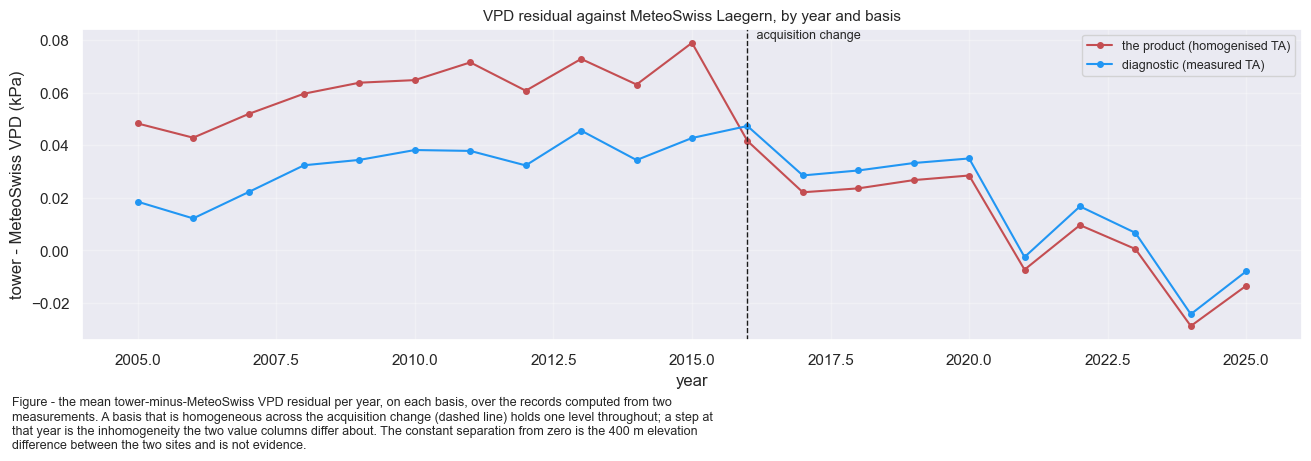

In [16]:
# The residual year by year, so the step can be seen rather than only tabulated.
fig, ax = plt.subplots(figsize=(13, 4.5), dpi=100, layout='constrained')
for _label, _col, _c in [('the product (homogenised TA)', TARGET, '#C44E52'),
                         ('diagnostic (measured TA)', DIAG_MEASURED_TA, '#2196F3')]:
    _yr = _residual(_col).groupby(_residual(_col).index.year).mean()
    ax.plot(_yr.index, _yr.values, marker='o', ms=4, color=_c, label=_label)
ax.axvline(BREAK_YEAR, color='k', ls='--', lw=1)
ax.text(BREAK_YEAR + 0.1, ax.get_ylim()[1], ' acquisition change', va='top', fontsize=9)
ax.set_xlabel('year')
ax.set_ylabel('tower - MeteoSwiss VPD (kPa)')
ax.set_title('VPD residual against MeteoSwiss Laegern, by year and basis', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=.3)
figcap(fig, "the mean tower-minus-MeteoSwiss VPD residual per year, on each basis, over the "
            "records computed from two measurements. A basis that is homogeneous across the "
            "acquisition change (dashed line) holds one level throughout; a step at that year is "
            "the inhomogeneity the two value columns differ about. The constant separation from "
            "zero is the 400 m elevation difference between the two sites and is not evidence.")


***

## ➡️ Prepare dataframe for export

In [17]:
VALCOL = TARGET   # VPD_T1_47_1 - a computed series, so no _gfXG suffix
FLAGCOL = f"FLAG_{TARGET}_ISFILLED"
SOURCECOL = f"FLAG_{TARGET}_SOURCE"

# One value column, not two. The measured-TA series is a diagnostic and is not exported: it rests
# on a temperature known to be 1.3 degC too cold before 2016, and shipping it beside the product
# would offer a worse series that happens to report a smaller step. The SOURCE flag is carried
# over from 02/04 unchanged rather than rebuilt, since it is their statement about the probe.
export_df = pd.concat([df[VALCOL],
                       flag.astype(int).rename(FLAGCOL),
                       df[TA_SOURCECOL].astype(int).rename(SOURCECOL)], axis=1)
export_df

,VPD_T1_47_1,FLAG_VPD_T1_47_1_ISFILLED,FLAG_VPD_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,0.011629,6,3
2004-01-01 00:45:00,0.015826,6,3
2004-01-01 01:15:00,0.033203,6,3
2004-01-01 01:45:00,0.037553,6,3
2004-01-01 02:15:00,0.030354,6,3
...,...,...,...
2025-12-31 21:45:00,0.280473,0,0
2025-12-31 22:15:00,0.295503,0,0
2025-12-31 22:45:00,0.209658,0,0


Sanity check: the exported series must be complete (no gaps), non-negative, physically plausible in
kPa, and the index must be continuous 30MIN with no duplicates. Every record must carry a flag.

`FLAG_VPD_T1_47_1_ISFILLED` travels with the product so downstream users can tell the three classes
apart. Flag `0` is computed from two measurements; `5` and `6` are computed but rest on a filled or
reconstructed input; `1`, `2` and `4` were produced by the gap-filling here.

In [18]:
print(f"Records:         {len(export_df):,}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      "
      f"{(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Index:           {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:       {export_df[VALCOL].min():.3f} / {export_df[VALCOL].max():.3f} kPa")

assert export_df[VALCOL].notna().all(), "the exported series is not complete"
assert (export_df[VALCOL] >= 0).all(), "VPD cannot be negative"
assert export_df[FLAGCOL].notna().all(), "a record has no flag"
assert export_df[FLAGCOL].isin(COMPUTED_FLAGS).all(), "every VPD record must be computed"

# The SOURCE flag must be defined everywhere and hold only the four codes 02 and 04 define.
assert export_df[SOURCECOL].notna().all(), "a record has no SOURCE code"
assert set(export_df[SOURCECOL].unique()).issubset(set(SOURCE_LEGEND)), "unknown SOURCE code"

# The product must be the homogenised-TA series and not the diagnostic. Asserting on the values
# rather than on the variable name is what makes this catch a mis-wired export.
assert export_df[VALCOL].equals(df[TARGET]), "the exported column is not the product series"
assert not export_df[VALCOL].equals(df[DIAG_MEASURED_TA]), \
    "the exported column is the measured-TA diagnostic"
print("\nSanity checks passed: complete, non-negative, every record computed, "
      "built on the homogenised TA.")

Records:         385,728
Missing values:  0
Missing flags:   0
Negative values: 0
Duplicate index: 0
Index gaps:      0
Index:           2004-01-01 00:15:00 -> 2025-12-31 23:45:00
Min / max:       0.000 / 4.345 kPa

Sanity checks passed: complete, non-negative, every record computed, built on the homogenised TA.


### Per-year statistics

The per-year median is the check that nothing stepped: `VPD` is weather, so the interannual spread
should be small and there should be no jump at 2018/2019, where the NABEL sensor behind the `RH`
reconstruction ends and the fill switches from `6` to `1`.

`measured_%` shows how much of each year rests on two genuine measurements. It is lowest where
notebook `04` had to reconstruct `RH` and where notebook `02` had to fill `TA`.

In [19]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['measured_%'] = (100 * (export_df[FLAGCOL] == 0)
                     .groupby(export_df.index.year).mean()).round(2)
_yr['reconstructed_RH_%'] = (100 * export_df[FLAGCOL].isin((6, 7))
                             .groupby(export_df.index.year).mean()).round(2)
tabcap("the exported VPD by year: record count, level and spread, the share computed from two measurements, and the share resting on a reconstructed RH. VPD is weather, so the year-to-year spread in the median should be small and should not step at a boundary")
display(_yr.round(3))

_med = _yr['median']
print(f"Yearly medians between {_med.min():.3f} and {_med.max():.3f} kPa "
      f"(spread {_med.max() - _med.min():.3f} kPa)")

Table - the exported VPD by year: record count, level and spread, the share computed from two
measurements, and the share resting on a reconstructed RH. VPD is weather, so the year-to-year
spread in the median should be small and should not step at a boundary



,count,median,min,max,std,measured_%,reconstructed_RH_%
TIMESTAMP_MIDDLE,,,,,,,
2004,17568,0.185,0.000,2.931,0.443,28.02,71.98
2005,17520,0.184,0.005,3.168,0.467,99.81,0.19
2006,17520,0.196,0.000,3.569,0.490,99.85,0.15
2007,17520,0.197,0.000,3.389,0.438,99.93,0.07
2008,17568,0.198,0.002,2.541,0.391,99.89,0.11
2009,17520,0.209,0.000,2.985,0.437,97.23,2.77
2010,17520,0.153,0.000,3.079,0.449,99.04,0.96
2011,17520,0.248,0.000,3.238,0.480,99.88,0.12
2012,17568,0.189,0.000,3.318,0.446,92.81,7.17


Yearly medians between 0.098 and 0.256 kPa (spread 0.158 kPa)


Table - records per year and provenance code, the counts behind the figure above



,0 = computed from measured TA and measured RH,5 = computed from measured RH and gap-filled TA,6 = computed from RH reconstructed from NABEL at 49 m (TA measured or gap-filled),7 = computed from RH reconstructed from MeteoSwiss Laegern at 2.5 km (TA measured or gap-filled)
year,,,,
2004,4922,0,12640,6
2005,17486,0,10,24
2006,17493,0,27,0
2007,17507,0,13,0
2008,17548,0,20,0
2009,17034,0,486,0
2010,17351,0,169,0
2011,17499,0,11,10
2012,16305,3,1260,0


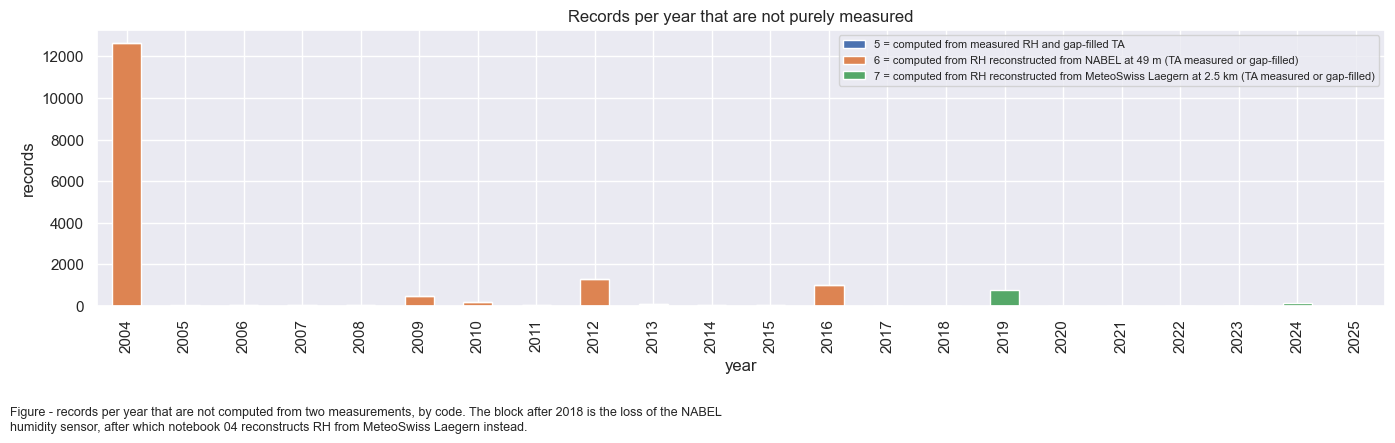

In [20]:
# Records per year and flag, plus the filled ones as a stacked bar chart.
_tab = (pd.crosstab(export_df.index.year, export_df[FLAGCOL])
        .rename(columns=lambda f: FLAG_LEGEND.get(f, f))
        .rename_axis(index='year', columns=None))
_not_measured = _tab.drop(columns=[c for c in _tab.columns if str(c).startswith('0 =')],
                          errors='ignore')
if not _not_measured.empty and _not_measured.to_numpy().sum() > 0:
    ax = _not_measured.plot(kind='bar', stacked=True, figsize=(14, 4),
                            title='Records per year that are not purely measured')
    ax.set_ylabel('records')
    ax.legend(fontsize=8)
    plt.tight_layout()
    figcap(ax.get_figure(),
           "records per year that are not computed from two measurements, by code. The block "
           "after 2018 is the loss of the NABEL humidity sensor, after which notebook 04 "
           "reconstructs RH from MeteoSwiss Laegern instead.")
tabcap("records per year and provenance code, the counts behind the figure above")
display(_tab)

***

## 💾 Save to file

In [21]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\07_METEO_VPD_2004-2025.parquet (0.071 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\07_METEO_VPD_2004-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [22]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"missing:   {int(_written[VALCOL].isna().sum())}")
print(f"median:    {float(_written[VALCOL].median()):.3f} kPa")
print(f"min / max: {float(_written[VALCOL].min()):.3f} / {float(_written[VALCOL].max()):.3f} kPa")

assert list(_written.columns) == [VALCOL, FLAGCOL, SOURCECOL], \
    "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].equals(export_df[VALCOL]), "values differ from what was written"
assert _written[FLAGCOL].equals(export_df[FLAGCOL]), "flags differ from what was written"
assert _written[SOURCECOL].equals(export_df[SOURCECOL]), "SOURCE flags differ"
check_vpd_range(_written[VALCOL], f"{VALCOL} (read back)")
print("\nWritten file verified.")

tabcap("the yearly median of the exported measured-basis VPD, read back from the written "
       "parquet rather than taken from the frame in memory")
display(_written[VALCOL].groupby(_written.index.year).median().round(3)
        .rename('yearly median (kPa)'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\07_METEO_VPD_2004-2025.parquet (0.008 seconds).

columns:   ['VPD_T1_47_1', 'FLAG_VPD_T1_47_1_ISFILLED', 'FLAG_VPD_T1_47_1_SOURCE']
index:     2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
missing:   0
median:    0.179 kPa
min / max: 0.000 / 4.345 kPa
  VPD_T1_47_1 (read back)            n=385,728  median 0.179  range 0.000..4.345 kPa

Written file verified.
Table - the yearly median of the exported measured-basis VPD, read back from the written parquet
rather than taken from the frame in memory



TIMESTAMP_MIDDLE
2004    0.185
2005    0.184
2006    0.196
2007    0.197
2008    0.198
2009    0.209
2010    0.153
2011    0.248
2012    0.189
2013    0.133
2014    0.204
2015    0.256
2016    0.128
2017    0.186
2018    0.177
2019    0.170
2020    0.200
2021    0.131
2022    0.217
2023    0.174
2024    0.098
2025    0.151
Name: yearly median (kPa), dtype: float64

***

## ⚠️ Note for downstream notebooks

`VPD_T1_47_1` is **complete** and **fully computed** — every record follows from `TA` and `RH` by
the formula; no `VPD` model runs.

`FLAG_VPD_T1_47_1_ISFILLED` tells a consumer what each record was computed from:

- `0` — measured `TA` and measured `RH` at 47 m. The only records where nothing upstream was
  modelled or transferred.
- `5` — measured `RH`, with a `TA` that notebook `02` gap-filled. Skilful, but not two measurements.
- `6` — `RH` reconstructed from the NABEL sensor at 49 m (notebook `04`), ~3 % RH uncertainty.
- `7` — `RH` reconstructed from MeteoSwiss Lägern at 2.5 km (notebook `04`), a weaker transfer than
  `6`. Almost all post-2018, plus the 2004 record start.

Two filters cover most uses: `flag == 0` for genuine measurements only, and — since every record
is computed — `flag > 0` for a value that rests on a gap-filled `TA` or a reconstructed `RH`.

#

### The November 2019 outage

One block deserves naming. The 47 m humidity sensor was down from **4 November 2019 04:45 to
19 November 2019 23:45** — **759 consecutive records, 15.8 days**, over half that month, by far the
longest stretch where the tower measured no `RH`.

Before 2019 a gap this long would have been reconstructed from NABEL. After 2018 NABEL is gone, so
notebook `04` reconstructs it from MeteoSwiss Lägern instead: the `VPD` here is **computed from a
Lägern-reconstructed `RH`** and carries flag `7`, not modelled. These 759 records are the bulk of
the flag-7 block — a transfer from a real humidity measurement 2.5 km away, weaker than the
same-tower NABEL transfer but not a model output.

## End of notebook.

In [23]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-29 20:52:04
Finished: 2026-07-29 20:52:12
Runtime:  00:00:07 (hh:mm:ss)
